# Structure Tensor Analysis and Anisotropy Quantification

## Objective

The Gabor analysis in Notebook 02 suggested that the barcoding phenomenon is characterized by strong directional structure and a preferred orientation.

The objective of this notebook is to quantify that directional organization using structure tensor analysis.

Unlike Gabor filters, which detect texture at specific frequencies and orientations, structure tensors estimate local orientation directly from image gradients.

This provides a complementary approach for measuring the degree of directional organization present within the barcoding pattern.

## Goals

This notebook will address the following questions:

1. Can the transmission columns be detected through local orientation analysis?
2. Do the representative barcoding examples exhibit strong anisotropy?
3. Can anisotropy be summarized as a quantitative biomarker?
4. How do anisotropy-based measurements compare with the Gabor results obtained previously?

In [9]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from skimage import io
from skimage import color
from skimage import exposure

from skimage.feature import structure_tensor

DATA_DIR = Path("../data/amd_best")

image_paths = sorted(DATA_DIR.glob("*.tif"))
print(image_paths)


[PosixPath('../data/amd_best/amd_sample1.tif'), PosixPath('../data/amd_best/amd_sample2.tif'), PosixPath('../data/amd_best/amd_sample3.tif')]


In [10]:
def load_roi(path):

    img = io.imread(path)

    img_gray = color.rgb2gray(img)

    img_norm = exposure.rescale_intensity(
        img_gray,
        in_range="image",
        out_range=(0,1)
    )

    roi = img_norm[
        180:350,
        :
    ]

    return roi

In [11]:
roi = load_roi(image_paths[0])

Axx, Axy, Ayy = structure_tensor(
    roi,
    sigma=2
)

print(Axx.shape)

(170, 768)


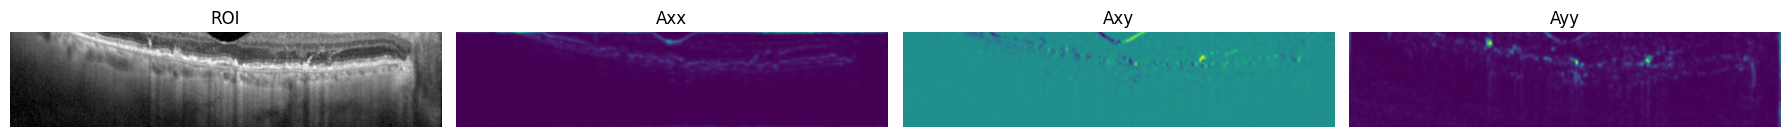

In [12]:
fig, ax = plt.subplots(
    1,
    4,
    figsize=(18,5)
)

ax[0].imshow(
    roi,
    cmap="gray"
)
ax[0].set_title("ROI")
ax[0].axis("off")

ax[1].imshow(
    Axx,
    cmap="viridis"
)
ax[1].set_title("Axx")
ax[1].axis("off")

ax[2].imshow(
    Axy,
    cmap="viridis"
)
ax[2].set_title("Axy")
ax[2].axis("off")

ax[3].imshow(
    Ayy,
    cmap="viridis"
)
ax[3].set_title("Ayy")
ax[3].axis("off")

plt.tight_layout()
plt.show()

In [13]:
trace = Axx + Ayy

det = Axx*Ayy - Axy**2

sqrt_term = np.sqrt(
    np.maximum(
        trace**2 - 4*det,
        0
    )
)

lambda1 = (trace + sqrt_term)/2
lambda2 = (trace - sqrt_term)/2

anisotropy = (
    (lambda1 - lambda2)
    /
    (lambda1 + lambda2 + 1e-10)
)

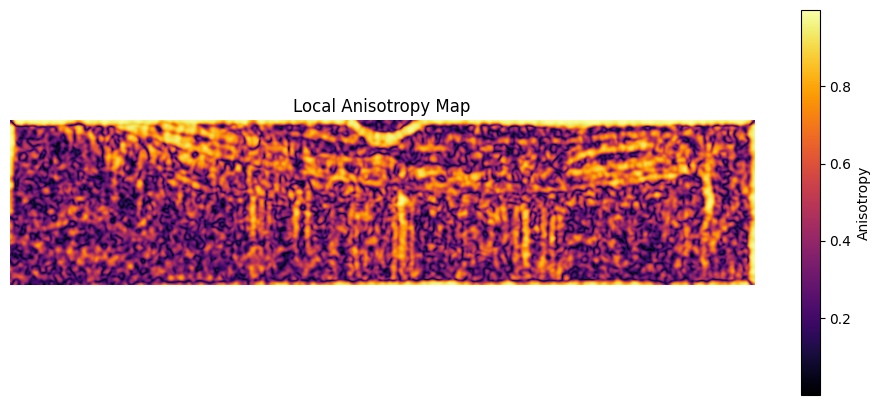

In [14]:
plt.figure(figsize=(12,5))

plt.imshow(
    anisotropy,
    cmap="inferno"
)

plt.colorbar(
    label="Anisotropy"
)

plt.title(
    "Local Anisotropy Map"
)

plt.axis("off")

plt.show()

In [15]:
anisotropy_score = np.mean(anisotropy)

print(anisotropy_score)

0.4509234905703024


The anistropy map is dominated by all edges, not just barcoding. The bright regions correspond to retinal layer boundaries, foveal depression, RPE interface, and transmission columns. Let's visualize where the strongest anistropy is occuring

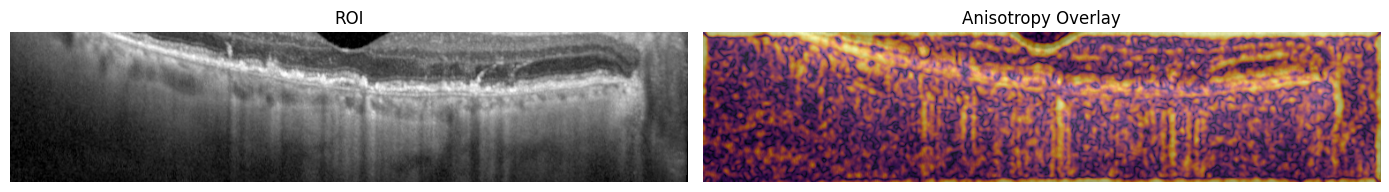

In [16]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(14,5)
)

ax[0].imshow(
    roi,
    cmap="gray"
)
ax[0].set_title("ROI")
ax[0].axis("off")

ax[1].imshow(
    roi,
    cmap="gray"
)

ax[1].imshow(
    anisotropy,
    cmap="inferno",
    alpha=0.6
)

ax[1].set_title("Anisotropy Overlay")
ax[1].axis("off")

plt.tight_layout()
plt.show()

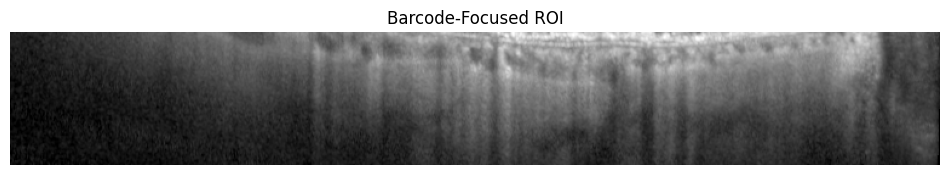

In [17]:
roi_barcode = roi[
    60:170,
    :
]
plt.figure(figsize=(12,4))

plt.imshow(
    roi_barcode,
    cmap="gray"
)

plt.title("Barcode-Focused ROI")
plt.axis("off")

plt.show()

In [18]:
Axx, Axy, Ayy = structure_tensor(
    roi_barcode,
    sigma=2
)

trace = Axx + Ayy

det = Axx * Ayy - Axy**2

sqrt_term = np.sqrt(
    np.maximum(
        trace**2 - 4 * det,
        0
    )
)

lambda1 = (trace + sqrt_term) / 2
lambda2 = (trace - sqrt_term) / 2

anisotropy_barcode = (
    (lambda1 - lambda2)
    /
    (lambda1 + lambda2 + 1e-10)
)

barcode_anisotropy_score = np.mean(
    anisotropy_barcode
)

print(
    f"Barcode ROI Anisotropy: {barcode_anisotropy_score:.4f}"
)

Barcode ROI Anisotropy: 0.4301


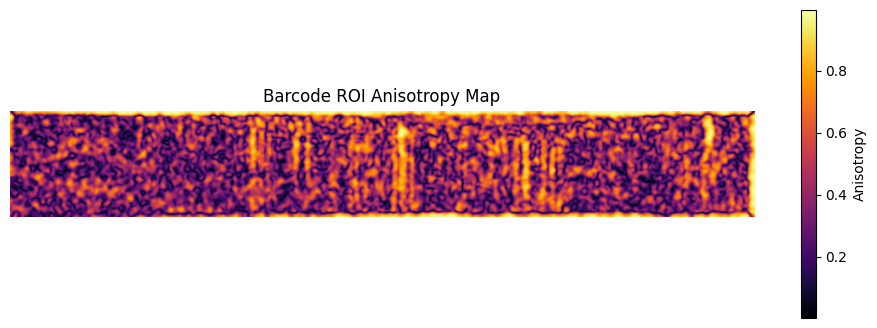

In [19]:
plt.figure(figsize=(12,4))

plt.imshow(
    anisotropy_barcode,
    cmap="inferno"
)

plt.colorbar(
    label="Anisotropy"
)

plt.title(
    "Barcode ROI Anisotropy Map"
)

plt.axis("off")

plt.show()

In [20]:
comparison = pd.DataFrame({
    "ROI": [
        "Full ROI",
        "Barcode ROI"
    ],
    "Mean Anisotropy": [
        anisotropy_score,
        barcode_anisotropy_score
    ]
})

comparison

,ROI,Mean Anisotropy
0,Full ROI,0.450923
1,Barcode ROI,0.430112


In [21]:
# see if this same thing is happening for all three images
def compute_anisotropy_score(roi, sigma=2):
    Axx, Axy, Ayy = structure_tensor(roi, sigma=sigma)

    trace = Axx + Ayy
    det = Axx * Ayy - Axy**2

    sqrt_term = np.sqrt(np.maximum(trace**2 - 4 * det, 0))

    lambda1 = (trace + sqrt_term) / 2
    lambda2 = (trace - sqrt_term) / 2

    anisotropy = (lambda1 - lambda2) / (lambda1 + lambda2 + 1e-10)

    return np.mean(anisotropy), anisotropy

In [22]:
anisotropy_results = []

for path in image_paths:
    roi = load_roi(path)

    roi_barcode = roi[60:170, :]

    score, anisotropy_map = compute_anisotropy_score(
        roi_barcode,
        sigma=2
    )

    anisotropy_results.append({
        "image": path.name,
        "mean_anisotropy": score
    })

anisotropy_df = pd.DataFrame(anisotropy_results)

anisotropy_df

,image,mean_anisotropy
0,amd_sample1.tif,0.430112
1,amd_sample2.tif,0.341469
2,amd_sample3.tif,0.381750


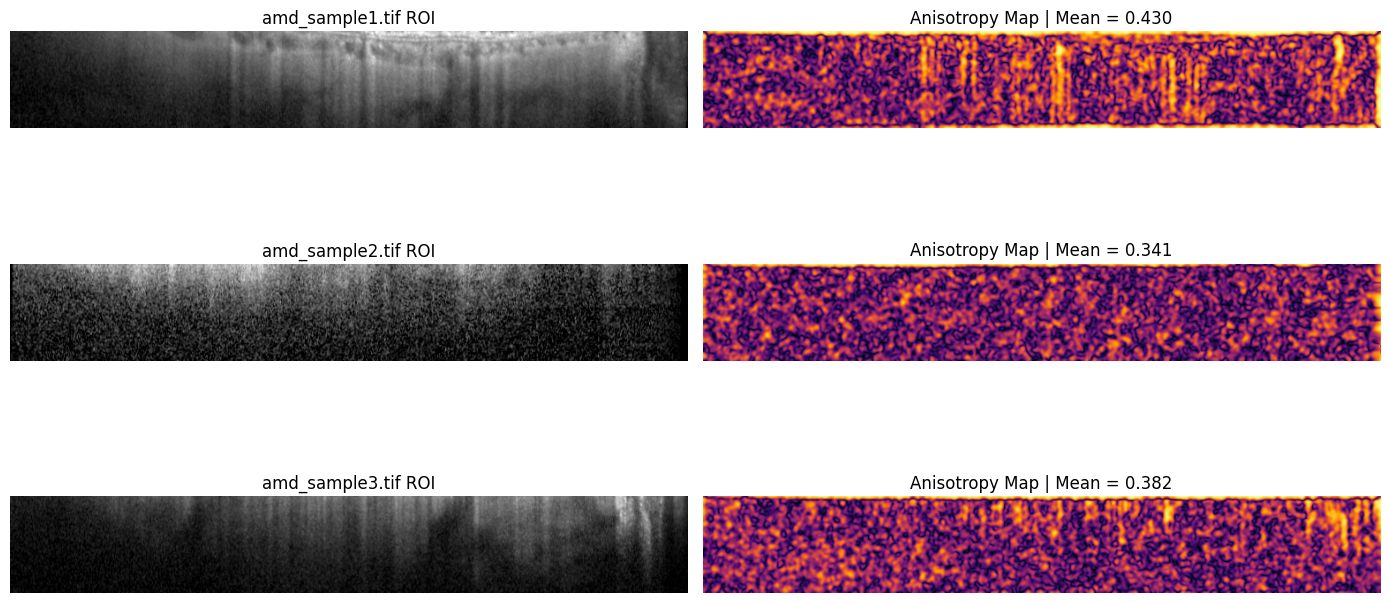

In [23]:
fig, axes = plt.subplots(
    len(image_paths),
    2,
    figsize=(14, 8)
)

for i, path in enumerate(image_paths):
    roi = load_roi(path)
    roi_barcode = roi[60:170, :]

    score, anisotropy_map = compute_anisotropy_score(
        roi_barcode,
        sigma=2
    )

    axes[i, 0].imshow(roi_barcode, cmap="gray")
    axes[i, 0].set_title(f"{path.name} ROI")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(anisotropy_map, cmap="inferno")
    axes[i, 1].set_title(f"Anisotropy Map | Mean = {score:.3f}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

The ranking is 1>3>2 for both methods which suggests we're detecting a genuine image property rather than a quirk of one algorithm.

In [24]:
comparison_df = pd.DataFrame({
    "image": [
        "amd_sample1.tif",
        "amd_sample2.tif",
        "amd_sample3.tif"
    ],
    "gabor_score": [
        0.014115,
        0.002806,
        0.004837
    ],
    "anisotropy_score": [
        0.430112,
        0.341469,
        0.381750
    ]
})

comparison_df

,image,gabor_score,anisotropy_score
0,amd_sample1.tif,0.014115,0.430112
1,amd_sample2.tif,0.002806,0.341469
2,amd_sample3.tif,0.004837,0.381750


In [25]:
comparison_df["gabor_norm"] = (
    comparison_df["gabor_score"]
    /
    comparison_df["gabor_score"].max()
)

comparison_df["anisotropy_norm"] = (
    comparison_df["anisotropy_score"]
    /
    comparison_df["anisotropy_score"].max()
)

comparison_df["composite_score"] = (
    comparison_df["gabor_norm"]
    +
    comparison_df["anisotropy_norm"]
) / 2

comparison_df

,image,gabor_score,anisotropy_score,gabor_norm,anisotropy_norm,composite_score
0,amd_sample1.tif,0.014115,0.430112,1.000000,1.000000,1.000000
1,amd_sample2.tif,0.002806,0.341469,0.198796,0.793907,0.496351
2,amd_sample3.tif,0.004837,0.381750,0.342685,0.887560,0.615122


# Conclusions

This notebook investigated whether local directional structure can be used to quantify the OCT barcoding phenomenon through structure tensor analysis and anisotropy metrics.

## Key Findings

Several important observations emerged from the analysis:

- The anisotropy maps successfully highlighted many of the visually apparent transmission columns present within the barcode-focused ROI.
- Samples exhibiting stronger and more coherent vertical transmission structures generally produced larger anisotropy scores.
- The barcode-focused ROI reduced the influence of retinal anatomy while preserving the transmission patterns of interest.
- The resulting anisotropy measurements were relatively stable and remained informative after restricting attention to the choroidal region.

Most importantly, the anisotropy rankings were consistent with the rankings obtained from the Gabor analysis performed in Notebook 02.

| Image | Gabor Rank | Anisotropy Rank |
|---------|---------:|---------:|
| amd\_sample1.tif | 1 | 1 |
| amd\_sample3.tif | 2 | 2 |
| amd\_sample2.tif | 3 | 3 |

This agreement is notable because the two methods quantify different aspects of image structure:

- Gabor filters measure oriented texture energy at specific spatial scales.
- Structure tensors measure local directional organization independent of a predefined frequency.

The consistency between these approaches suggests that both methods are capturing a genuine property of the barcoding pattern rather than an artifact of a particular algorithm.

## Prototype Composite Barcoding Index

To explore how multiple image-derived features may be combined, normalized Gabor and anisotropy scores were averaged to produce a preliminary composite barcoding index:

$$
BI
=
\frac{
\tilde{G}
+
\tilde{A}
}{2},
$$

where:

- $\tilde{G}$ is the normalized Gabor score,
- $\tilde{A}$ is the normalized anisotropy score.

The resulting composite scores preserved the ordering observed in the individual analyses:

$$
\text{Sample 1}
>
\text{Sample 3}
>
\text{Sample 2}.
$$

While these values should not yet be interpreted as a clinically meaningful severity scale, they demonstrate that independent image-analysis methods can be combined into a unified quantitative measure.

## Implications for Future Work

The analyses conducted thus far provide evidence that the barcoding phenomenon can be characterized using objective image-derived features.

Future work should focus on:

- Refining ROI selection and segmentation strategies.
- Evaluating additional directional texture measures.
- Investigating robustness across larger image collections.
- Developing a standardized barcoding index that combines complementary image features.
- Relating quantitative barcoding measurements to clinical outcomes and progression risk.

Taken together, the results from Notebooks 02 and 03 suggest that barcoding is best described as an oriented texture phenomenon and that both Gabor-based texture measures and anisotropy-based directional measures provide promising foundations for future biomarker development.